In [1]:
import spacy
from spacy.training import Example
from sklearn.metrics import confusion_matrix, classification_report
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def load_test_data(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    test_data = []
    for line in lines:
        entry = json.loads(line)
        text = entry[0]
        entities = entry[1]["entities"]
        test_data.append((text, {"entities": entities}))
    return test_data

def create_test_examples(nlp, test_data):
    examples = []
    for text, annotations in test_data:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)
        examples.append(example)
    return examples

In [3]:
model_1_2j_2 = spacy.load("model_1.2j.2")
models = [model_1_2j_2]

C:\Users\deepp\AppData\Roaming\Python\Python312\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\deepp\AppData\Roaming\Python\Python312\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [4]:
def remove_duplicate_entities(records):
    for record in records:
        text, annotations = record
        unique_entities = []
        seen = set()
        for entity in annotations['entities']:
            entity_tuple = tuple(entity) 
            if entity_tuple not in seen:
                unique_entities.append(entity)
                seen.add(entity_tuple)
        annotations['entities'] = unique_entities
    return records

def read_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def load_and_clean_test_data(file_path):
    data = read_jsonl(file_path)
    cleaned_data = remove_duplicate_entities(data)
    return cleaned_data


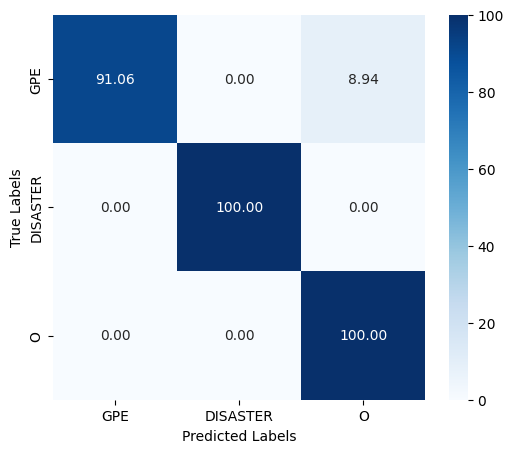

              precision    recall  f1-score   support

         GPE       1.00      0.91      0.95      1712
    DISASTER       1.00      1.00      1.00      2037
           O       1.00      1.00      1.00     55333

    accuracy                           1.00     59082
   macro avg       1.00      0.97      0.98     59082
weighted avg       1.00      1.00      1.00     59082



In [7]:
for nlp in models:
    test_data = load_and_clean_test_data("../datasets/test/5xjp.jsonl")
    test_examples = create_test_examples(nlp, test_data)

    true_entities = []
    predicted_entities = []

    for example in test_examples:
        true_ents = [(ent.start_char, ent.end_char, ent.label_) for ent in example.reference.ents]
        true_entities.append(true_ents)  
        
        pred_doc = nlp(example.text)
        pred_ents = [(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents]
        predicted_entities.append(pred_ents)  

    aligned_true = []
    aligned_pred = []

    for true_ents, pred_ents in zip(true_entities, predicted_entities):
        true_labels = ['O'] * len(example.text) 
        pred_labels = ['O'] * len(example.text) 
        
        for i, (true_start, true_end, true_label) in enumerate(true_ents):
            true_labels[i] = true_label  
            
            for pred_start, pred_end, pred_label in pred_ents:
                if pred_start == true_start and pred_end == true_end:
                    pred_labels[i] = pred_label 
                    
        aligned_true.extend(true_labels)
        aligned_pred.extend(pred_labels)

    labels = ['GPE', 'DISASTER', 'O']
    label_to_index = {label: i for i, label in enumerate(labels)}

    true_indices = [label_to_index[label] if label in label_to_index else label_to_index['O'] for label in aligned_true]
    pred_indices = [label_to_index[label] if label in label_to_index else label_to_index['O'] for label in aligned_pred]

    conf_matrix = confusion_matrix(true_indices, pred_indices, labels=range(len(labels)), normalize='true')

    conf_matrix_percentage = conf_matrix * 100

    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    print(classification_report(true_indices, pred_indices, target_names=labels))